In [1]:
import numpy as np
#import cupy as cp
import matplotlib.pyplot as plt

from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = False #False if your computer sucks (mine does)

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [3]:
m1 = 1e6
m2 = 10
a = 0.8
e0 = 0.4
xI0 = 1.0
dist = 0.4
qS = np.pi/4
phiS = 1.0
qK = 1 
phiK = np.pi/3
Phi_phi0 = 0.9
Phi_theta0 =0.5
Phi_r0 = 0.4

dt = 10.0
T = 0.5

chi2 = 0.0

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7.0


In [4]:
SK_traj = EMRIInspiral(func=SuperKludgeFlux)
add_args= [chi2, evolve_1PA, evolve_primary, evolve_2PA,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
p0_ = get_p_at_t(traj_module=SK_traj, t_out=T, traj_args=[m1, m2, a, e0, xI0, *add_args])
p0_

6.339844569909762

In [5]:
filename= "rishav_CVBias"

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

# with longer signals we care less about this
t0 = 10000.0  # throw away on both ends when our orbital information is weird

In [6]:
pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"])
                   

der_order = 6
Ndelta = 12
stability_plot = True

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0']
emri_kwargs = {"T":T, "dt":dt}

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs)
print("SNR: ", SNR)

wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.8, 7.0, 0.4, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
SNR:  88.59340740578087


In [7]:
# got from Shubham's code
def cutlervallis(waveform_truth, waveform_approx, Fisher_truth, partial_approx, params_truth, PSD_func, dt, use_gpu=False):
    """
    Calculate best-fit param points using the Cutler-Vallisneri linear-bias approximation.
    params:
        waveform_truth (ndarray) : the time-series waveform from the true template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        waveform_approx (ndarray) : the time-series waveform from the approximate template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        partial_approx (ndarray) : the time-series partial derivative of the approximate template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        Fisher_truth (ndarray) : the Fisher matrix (log-mass units) at params_truth. ndarray of shape 'd x d'
        params_truth (ndarray) : the array of true params. ndarray of shape 'd'
        PSD_func (ndarray) : the frequency-domain LISA noise sensitivity curve. ndarray of shape 'N x L' where L is the length of the frequency series. 

    returns:
        CV_bias (ndarray): params_truth + np.linalg.inv(Fisher_truth) @ inner_product(partial_approx, waveform_truth - waveform_approx)
    """

#Equation 29 of cutler-vallisneri paper
    if use_gpu:
        xp = cp
    else:
        xp = np
        
    #waveform_truth = padding(waveform_truth, waveform_approx, use_gpu = use_gpu) #make waveform_truth the same length as waveform_approx
    delta_wave = waveform_truth - waveform_approx
    #truth contains 1 order PN and approx contains 0 order PN with deviations

    # calculate all the column-wise inner products
    inn_prods = []
    
    for j in range(len(Fisher_truth)):
        
        print("delta_wave.shape, partial_approx.shape: ", delta_wave.shape, partial_approx[j].shape)
                      
        inn_prod_j = inner_product(partial_approx[j], delta_wave, PSD=PSD_func, dt=dt, use_gpu = use_gpu) #should be a scalar
        if not use_gpu:
            inn_prod_j = xp.asarray(inn_prod_j)
        else:
            inn_prod_j = xp.asnumpy(inn_prod_j)
            
        print(f'inner_prod at j = {j}: ', inn_prod_j)
        inn_prods.append(inn_prod_j)
        
    inn_prods = np.array(inn_prods)
    # calculate all the param shifts
    delta_param_all = []
    
    for i in range(len(Fisher_truth)):
            
        delta_param_i = np.linalg.inv(Fisher_truth)[i,:]@inn_prods  #should be a scalars
        print(f"{param_names[i]} have delta {delta_param_i}")
        delta_param_all.append(delta_param_i)
        
    print('delta_param_all: ', delta_param_all)
    return params_truth + np.array(delta_param_all)


T:  0.5 dt:  10.0
Body is not plunging, Fisher should be stable.
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.8, 7.0, 0.4, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 88.59340740578087
calculating stable deltas...
Gamma_ii for m1: 1130.011182369682
Gamma_ii for m1: 1130.0111823621667
Gamma_ii for m1: 1130.0111823886998
Gamma_ii for m1: 1130.0111823882562
Gamma_ii for m1: 1130.0111823255188
Gamma_ii for m1: 1130.0111817332483
Gamma_ii for m1: 1130.0111827000835
Gamma_ii for m1: 1130.0111891682916
Gamma_ii for m1: 1130.0111937823865
Gamma_ii for m1: 1130.011197133151
Gamma_ii for m1: 1130.0111877826398
Gamma_ii for m1: 1130.0113629139987
[np.float64(6.65071479975539e-12), np.float64(2.3480425765420157e-11), np.float64(3.9256783269364926e-13), np.float64(5.551927295669443e-11), np.float64(5.241279579352273e-10), np.float64(8.555978686671662e-10), np.float64(5

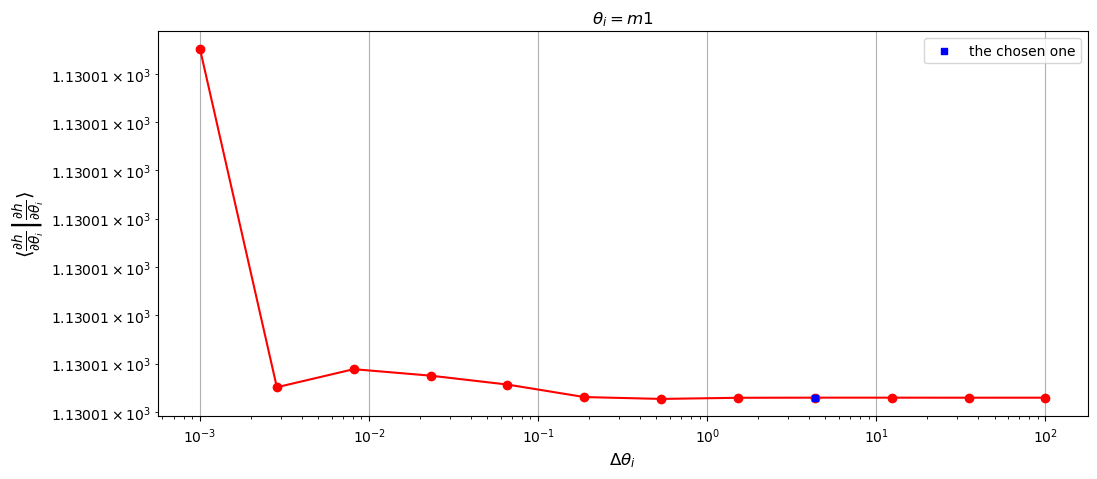

Gamma_ii for m2: 184233314975.48682
Gamma_ii for m2: 184233314956.85016
Gamma_ii for m2: 184233315001.36334
Gamma_ii for m2: 184233314937.5275
Gamma_ii for m2: 184233314941.8214
Gamma_ii for m2: 184233314979.59634
Gamma_ii for m2: 184233315734.03564
Gamma_ii for m2: 184233312554.80487
Gamma_ii for m2: 184233338930.21658
Gamma_ii for m2: 184233329425.0119
Gamma_ii for m2: 184233174369.41312
Gamma_ii for m2: 184233248182.89737
[np.float64(1.0115791337309812e-10), np.float64(2.416131066925686e-10), np.float64(3.4649458470044907e-10), np.float64(2.3306939878261647e-11), np.float64(2.0503855595016386e-10), np.float64(4.09502102011907e-09), np.float64(1.7256546765830087e-08), np.float64(1.4316307713793806e-07), np.float64(5.1593295909388464e-08), np.float64(8.416269182579048e-07), np.float64(4.006523522814483e-07)]
3


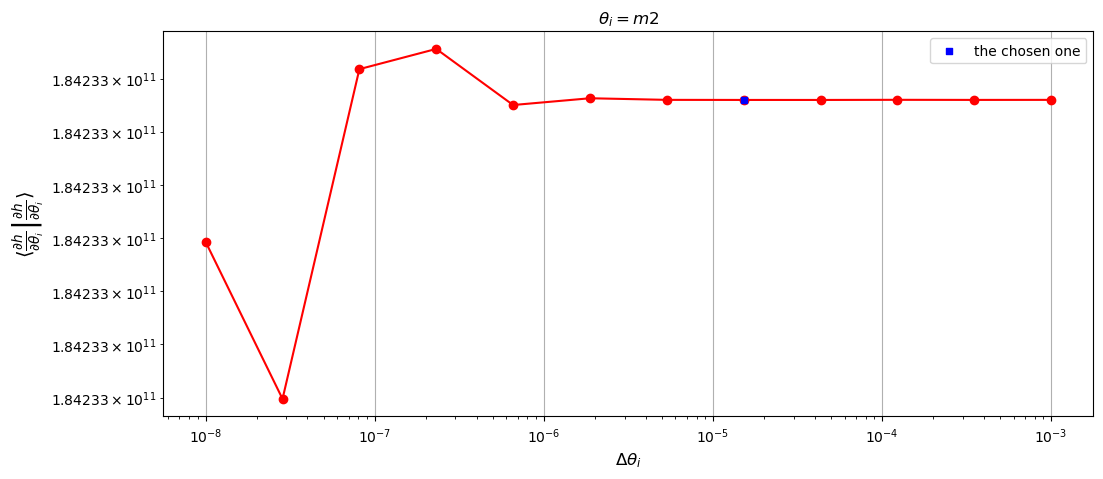

Gamma_ii for a: 19660601343157.69
Gamma_ii for a: 19660603265482.406
Gamma_ii for a: 19660614682715.473
Gamma_ii for a: 19660581688495.59
Gamma_ii for a: 19660794605021.426
Gamma_ii for a: 19660307824171.87
Gamma_ii for a: 19661654325402.05
Gamma_ii for a: 19653629320775.004
Gamma_ii for a: 19659765548528.5
Gamma_ii for a: 19674099924279.31
Gamma_ii for a: 19620252849585.664
Gamma_ii for a: 19636687630399.75
[np.float64(9.777546949531929e-08), np.float64(5.807159771277982e-07), np.float64(1.678191439377356e-06), np.float64(1.0829497490480776e-05), np.float64(2.475957415866105e-05), np.float64(6.848361831079815e-05), np.float64(0.0004083217657190669), np.float64(0.00031212110532800224), np.float64(0.0007285911836362539), np.float64(0.0027444638510243083), np.float64(0.0008369426210479149)]
0


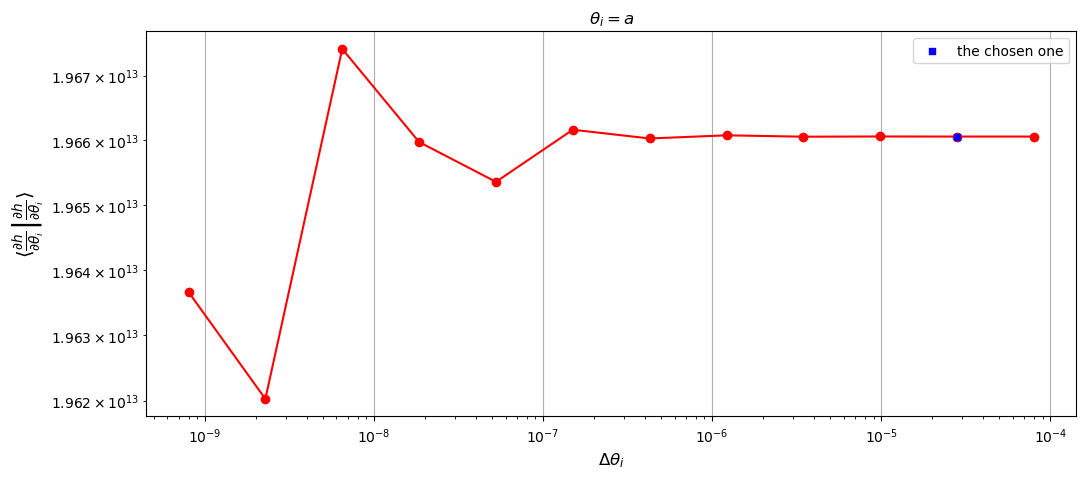

Gamma_ii for p0: 53519409369216.56
Gamma_ii for p0: 53519408723032.58
Gamma_ii for p0: 53519409682473.27
Gamma_ii for p0: 53519413491572.625
Gamma_ii for p0: 53519394425821.53
Gamma_ii for p0: 53519434555818.33
Gamma_ii for p0: 53519288459386.76
Gamma_ii for p0: 53518922512405.82
Gamma_ii for p0: 53519277691485.19
Gamma_ii for p0: 53516321225422.016
Gamma_ii for p0: 53553582506431.92
Gamma_ii for p0: 53462523290542.17
[np.float64(1.2073825174696085e-08), np.float64(1.7926967076146603e-08), np.float64(7.117229250208984e-08), np.float64(3.5624003780863667e-07), np.float64(7.498210160464465e-07), np.float64(2.72979024527163e-06), np.float64(6.837712041991738e-06), np.float64(6.636469972831786e-06), np.float64(5.524419458352934e-05), np.float64(0.0006957756935389163), np.float64(0.0017032345329996593)]
0


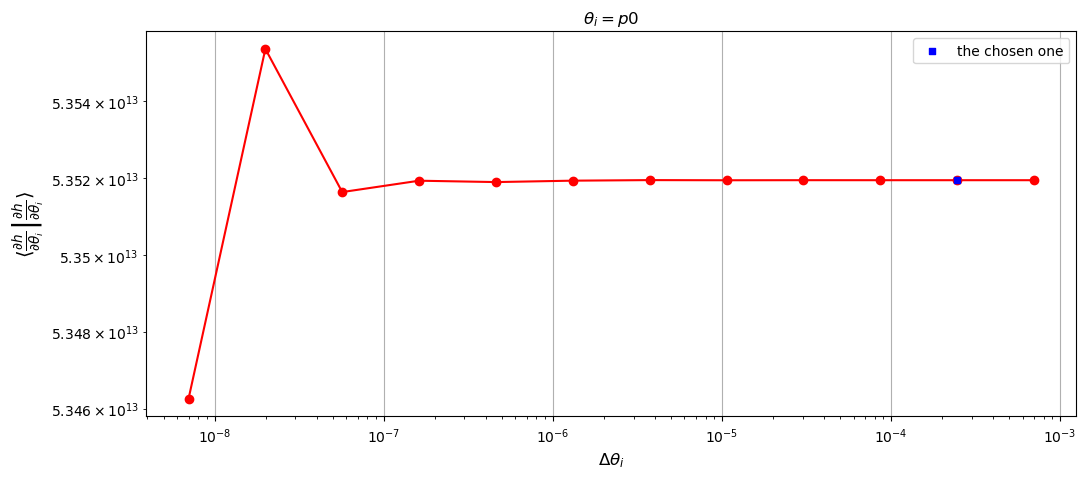

Gamma_ii for e0: 496687112233227.3
Gamma_ii for e0: 496687041228320.3
Gamma_ii for e0: 496686945325839.5
Gamma_ii for e0: 496687754593015.7
Gamma_ii for e0: 496688483232458.3
Gamma_ii for e0: 496692308909932.9
Gamma_ii for e0: 496697615818308.44
Gamma_ii for e0: 496661778037705.1
Gamma_ii for e0: 496573542682121.1
Gamma_ii for e0: 496530981897580.7
Gamma_ii for e0: 495628034835858.56
Gamma_ii for e0: 497781512330750.5
[np.float64(1.4295703552966264e-07), np.float64(1.9308435970586158e-07), np.float64(1.6293278195485428e-06), np.float64(1.466994841279589e-06), np.float64(7.702308664610759e-06), np.float64(1.0684384636756063e-05), np.float64(7.215731547715717e-05), np.float64(0.00017768839456773754), np.float64(8.57162716771146e-05), np.float64(0.0018218240257962038), np.float64(0.004326150010691962)]
0


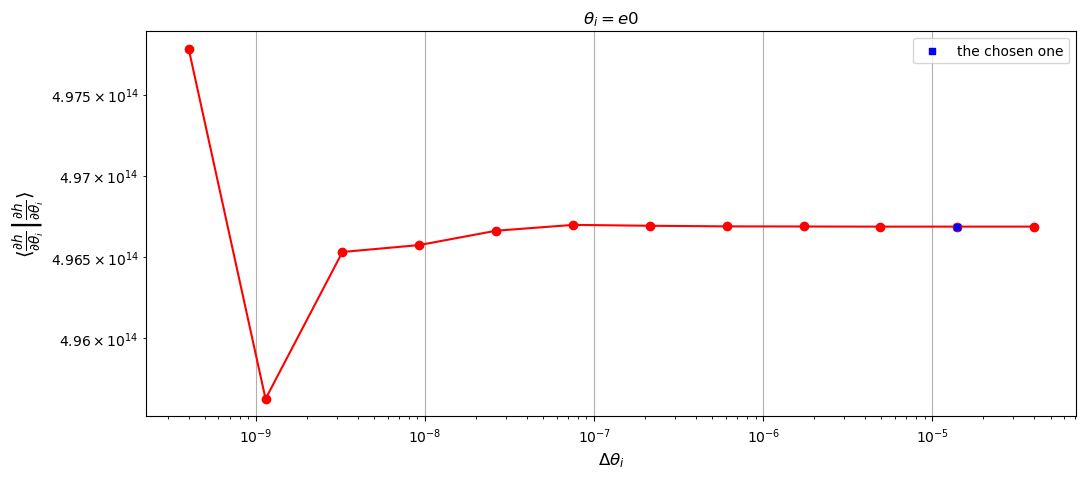

Gamma_ii for qS: 24110.159468989554
Gamma_ii for qS: 24110.16174158747
Gamma_ii for qS: 24110.16174589872
Gamma_ii for qS: 24110.16174590676
Gamma_ii for qS: 24110.161745906207
Gamma_ii for qS: 24110.161745910482
Gamma_ii for qS: 24110.161745906076
Gamma_ii for qS: 24110.161745921894
Gamma_ii for qS: 24110.161745887144
Gamma_ii for qS: 24110.161746330734
Gamma_ii for qS: 24110.161746610185
Gamma_ii for qS: 24110.161746255028
[np.float64(9.425892460889548e-08), np.float64(1.7881458765896182e-10), np.float64(3.3346657929566336e-13), np.float64(2.2935257942507688e-14), np.float64(1.7729557948974838e-13), np.float64(1.827276142656379e-13), np.float64(6.56069089039201e-13), np.float64(1.441299893861886e-12), np.float64(1.8398452675358872e-11), np.float64(1.1590604202646626e-11), np.float64(1.47306220829271e-11)]
3


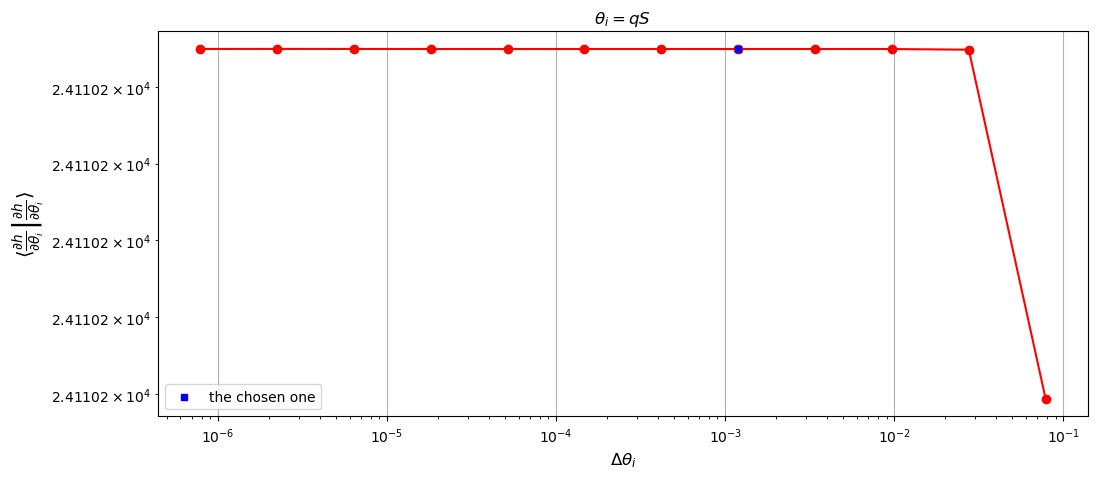

Gamma_ii for phiS: 465123.8782285642
Gamma_ii for phiS: 465123.8777807032
Gamma_ii for phiS: 465123.877779847
Gamma_ii for phiS: 465123.87777984544
Gamma_ii for phiS: 465123.8777798454
Gamma_ii for phiS: 465123.8777798455
Gamma_ii for phiS: 465123.87777984556
Gamma_ii for phiS: 465123.87777984544
Gamma_ii for phiS: 465123.87777984684
Gamma_ii for phiS: 465123.8777798491
Gamma_ii for phiS: 465123.87777983665
Gamma_ii for phiS: 465123.8777798485
[np.float64(9.628854951316715e-10), np.float64(1.8407493686691322e-12), np.float64(3.3788995141795324e-15), np.float64(1.251444264510938e-16), np.float64(2.5028885290218755e-16), np.float64(1.2514442645109377e-16), np.float64(2.502888529021876e-16), np.float64(3.003466234826242e-15), np.float64(4.8806326315926196e-15), np.float64(2.6780907260534578e-14), np.float64(2.5529462996022966e-14)]
5


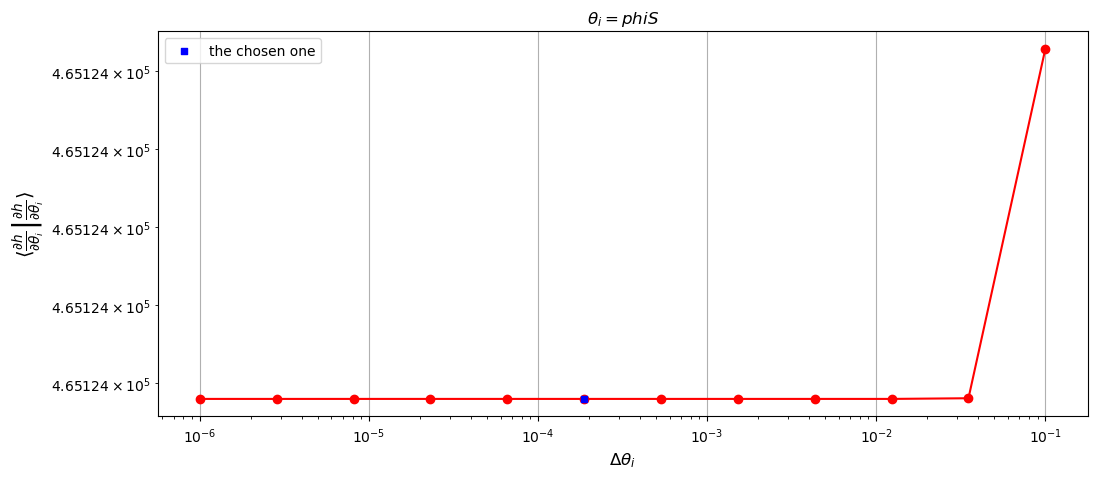

stable deltas: {'m1': 4.328761281083059, 'm2': 1.5199110829529332e-05, 'a': 2.8089533873721088e-05, 'p0': 0.0002457834213950592, 'e0': 1.4044766936860542e-05, 'qS': 0.0011937353730786609, 'phiS': 0.0001873817422860385, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 399.20412516593933 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 56.28785586357117 seconds


In [24]:
#initialize the 0PA (approximate) model
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

Fisher = sef(*pars_list,param_names = param_names,T = T, dt = dt, add_param_args=add_param_args,\
             der_order = der_order, Ndelta = Ndelta, stability_plot = stability_plot,
            live_dangerously = False)


In [25]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J

In [26]:
fisher_=Fisher.copy()
fisher_
# sef.deltas["Phi_phi0"] = 1e-5
# sef.deltas["Phi_r0"] = 1e-5
sef.deltas

{'m1': 4.328761281083059,
 'm2': 1.5199110829529332e-05,
 'a': 2.8089533873721088e-05,
 'p0': 0.0002457834213950592,
 'e0': 1.4044766936860542e-05,
 'qS': 0.0011937353730786609,
 'phiS': 0.0001873817422860385,
 'Phi_phi0': 0.0,
 'Phi_r0': 0.0}

In [27]:
#in this code cell, we are transfroming fisher for numerical stability and will remove parameters that are causing problem

print("Transforming to log-mass")
Fisher_transform = logmasstransform(fisher_, m1)
print("Checking log-mass Fisher positive-definiteness...")
check_flag = True
rows_to_remove = []
for j in range(len(param_names)):
    if param_names[j] in []:#'dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0']:
            rows_to_remove.append(j)

rows_to_remove = np.array(rows_to_remove)
    
if len(rows_to_remove) > 0:
    Fisher_transformed = np.delete(np.delete(Fisher_transform,rows_to_remove,axis=0),rows_to_remove,axis=1)
    #Fisher = np.delete(np.delete(Fisher,rows_to_remove,axis=0),rows_to_remove,axis=1)

if (np.linalg.eigvals(Fisher_transform) < 0.0).any():
    check_flag = False
    print('positive definiteness failed for: ', i)
        
if check_flag:
    print("positive-definiteness check passed!")
pd.DataFrame(Fisher_transform)

Transforming to log-mass
Checking log-mass Fisher positive-definiteness...
positive-definiteness check passed!


,0,1,2,3,4,5,6,7,8
0,1.130011e+15,-1.404326e+13,1.248991e+14,2.455477e+14,7.426526e+14,-4.237370e+09,1.953153e+10,-5.119555e+09,-3.670134e+09
1,-1.404326e+13,1.842333e+11,-1.721635e+12,-3.079417e+12,-8.941055e+12,4.774898e+07,-2.200732e+08,5.768557e+07,3.780927e+07
2,1.248991e+14,-1.721635e+12,1.966060e+13,2.811600e+13,7.730593e+13,-4.415745e+08,2.035934e+09,-5.339600e+08,-2.041290e+08
3,2.455477e+14,-3.079417e+12,2.811600e+13,5.351941e+13,1.605900e+14,-9.164982e+08,4.224559e+09,-1.107383e+09,-7.637156e+08
4,7.426526e+14,-8.941055e+12,7.730593e+13,1.605900e+14,4.966870e+14,-2.939486e+09,1.354971e+10,-3.551618e+09,-2.646276e+09
5,-4.237370e+09,4.774898e+07,-4.415745e+08,-9.164982e+08,-2.939486e+09,2.411016e+04,-1.005667e+05,2.636536e+04,1.884815e+04
6,1.953153e+10,-2.200732e+08,2.035934e+09,4.224559e+09,1.354971e+10,-1.005667e+05,4.651239e+05,-1.215735e+05,-8.687297e+04
7,-5.119555e+09,5.768557e+07,-5.339600e+08,-1.107383e+09,-3.551618e+09,2.636536e+04,-1.215735e+05,3.187610e+04,2.276050e+04
8,-3.670134e+09,3.780927e+07,-2.041290e+08,-7.637156e+08,-2.646276e+09,1.884815e+04,-8.687297e+04,2.276050e+04,2.465389e+04


In [28]:
delats=sef.deltas
param_name = sef.param_names

In [29]:
parameters = {}
for i in range(len(param_names_com)):
    parameters[param_names_com[i]] = pars_list_com[i]


order = 8 #order of finite-difference derivative
kind = "central" #kind of finite-difference derivative
parameters

{'m1': 1000000.0,
 'm2': 10,
 'a': 0.8,
 'p0': 7.0,
 'e0': 0.4,
 'xI0': 1.0,
 'dist': 0.4,
 'qS': 0.7853981633974483,
 'phiS': 1.0,
 'qK': 1,
 'phiK': 1.0471975511965976,
 'Phi_phi0': 0.9,
 'Phi_theta0': 0.5,
 'Phi_r0': 0.4,
 'chi2': 0.0,
 'evolve_1PA': False,
 'evolve_primary': False,
 'evolve_2PA': False,
 'deviation_included': True,
 'dev0p': 0.0,
 'dev0e': 0.0,
 'dev1p': 0.0,
 'dev1e': 0.0,
 'dev2p': 0.0,
 'dev2e': 0.0}

In [30]:
# del sef

In [31]:
print(f"Calculating Cutler-Vallisneri Biases")
removed_params = []
print(f'calculating derivatives at {param_names}...')
#Fisher = np.zeros((sef.npar,sef.npar), dtype=np.float64)
dtv = []

for k in range(sef.npar):
        temp=sef.derivative(*sef.wave_params_list,
                             param_to_vary=sef.param_names[k],
                               delta=sef.deltas[sef.param_names[k]],
                               kind=kind, **sef.waveform_derivative_kwargs)
        print(temp)
        print(f"calculting derivative for {sef.param_names[k]}\n")
        dtv_=np.vstack([temp.real,temp.imag])
        print(dtv_)
        dtv.append(dtv_)
        

print("Finished derivatives")
if sef.use_gpu:
        dtv = cp.asnumpy(cp.asarray(dtv)) #h5py only stores numpy
          
#Jacobian transform to log-masses
for k in range(sef.npar):
    if sef.param_names[k] == 'm1':
        dtv[k] *= m1 #to obtain \partial_{log m1}h

Calculating Cutler-Vallisneri Biases
calculating derivatives at ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']...
[1.62301658e-32+5.06480965e-33j 1.54310212e-28-1.96036328e-28j
 3.93677062e-28-2.64687612e-28j ... 4.08395524e-22-2.48058907e-23j
 4.14150814e-22+1.03847734e-22j 3.78160517e-22+2.36798884e-22j]
calculting derivative for m1

[[ 1.62301658e-32  1.54310212e-28  3.93677062e-28 ...  4.08395524e-22
   4.14150814e-22  3.78160517e-22]
 [ 5.06480965e-33 -1.96036328e-28 -2.64687612e-28 ... -2.48058907e-23
   1.03847734e-22  2.36798884e-22]]
[ 1.62301919e-22+5.06479750e-23j  1.37684739e-22+9.50471717e-23j
  1.02153878e-22+1.28052522e-22j ... -6.66828405e-18+2.84498729e-19j
 -6.68293241e-18-1.79556471e-18j -6.03093346e-18-3.90860245e-18j]
calculting derivative for m2

[[ 1.62301919e-22  1.37684739e-22  1.02153878e-22 ... -6.66828405e-18
  -6.68293241e-18 -6.03093346e-18]
 [ 5.06479750e-23  9.50471717e-23  1.28052522e-22 ...  2.84498729e-19
  -1.79556471e-18 -3.908602

In [32]:
params_truth_in = np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0])
#params_truth_in_transformed = np.array([np.log(m1), m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,dev_0_p,dev_0_e])

# param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

params_truth_in_considered = np.array([np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0,Phi_r0])
#params_truth_in_considered = np.array([np.log(m1), m2, a, p0, e0, dev_0_p, dev_0_e])

waveform_approx = sef.waveform
waveform_approx

array([[ 8.11517709e-22,  6.88429739e-22,  5.10772373e-22, ...,
         2.94380506e-24, -2.17120633e-22, -4.29859628e-22],
       [-2.53242407e-22, -4.75241645e-22, -6.40270386e-22, ...,
        -7.11324943e-22, -6.91542573e-22, -6.01602278e-22]],
      shape=(2, 1577908))

In [33]:
#initializing the 1PA (True GR model in our analysis)
evolve_1PA = True 
evolve_primary = False
evolve_2PA = False #for approximate model
dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
deviation_included=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=False)

waveform_true = superkludge_wave(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
waveform_true= np.array(waveform_true)

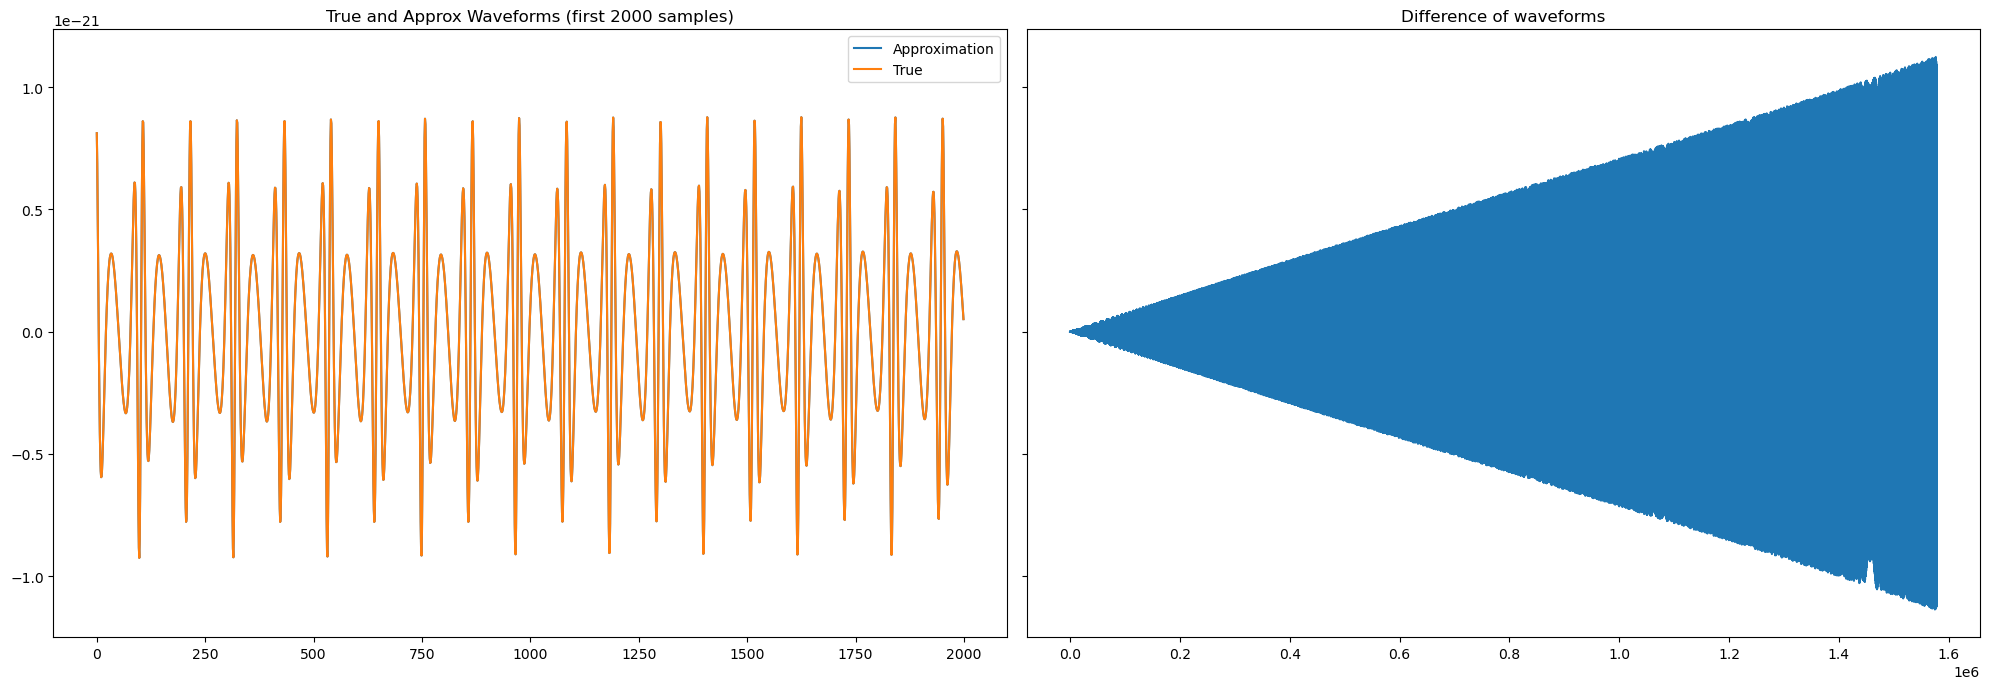

In [34]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

# Plot the first 2000 samples of both waveforms
axs[0].plot(waveform_approx[0][0:2000], label="Approximation")
axs[0].plot(waveform_true[0][0:2000], label="True")
axs[0].set_title("True and Approx Waveforms (first 2000 samples)")
axs[0].legend()

# Plot the difference
axs[1].plot((waveform_true[0] - waveform_approx[0])[0:])
axs[1].set_title("Difference of waveforms")

plt.tight_layout()

In [35]:
biased_params = cutlervallis(waveform_truth=waveform_true, waveform_approx=waveform_approx,
                                 Fisher_truth=Fisher_transform, partial_approx=dtv,
                                 params_truth=params_truth_in_considered, PSD_func = sef.PSD_funcs, dt = dt,
                                  use_gpu=use_gpu)
print(biased_params)

if use_gpu:
        biased_params = cp.asnumpy(cp.asarray(biased_params))

#prior box on chi2
# if 'chi2' not in removed_params:
#     index_chi2 = np.where(param_names == 'chi2')
        
#     if biased_params[index_chi2] > 1.0:
#         biased_params[index_chi2] = 1.0
#     elif biased_params[index_chi2] < -1.0:
#         biased_params[index_chi2] = -1.0

#prior box on cyclic parameters (phases and such)
cyclic_priors = {'qS' : np.pi, 'phiS' : 2 * np.pi, 'qK' : np.pi, 'phiK' : 2 * np.pi, 'Phi_phi0' : 2 * np.pi, 'Phi_r0' : 2 * np.pi}
param_names_in = np.array(param_names)
for param in list(cyclic_priors.keys()):
    if param not in removed_params:
        print(f"modulo {cyclic_priors[param]} for param {param}")
            
        index = np.where(param_names_in == param) 
        biased_params[index] %= cyclic_priors[param]


print('biased params: ', biased_params)

#calculate the sigma contour as the Mahalanobis distance between the true and biased params (https://en.wikipedia.org/wiki/Mahalanobis_distance):
    
sigma_contour = np.sqrt((biased_params - params_truth_in_considered)@Fisher_transform@(biased_params - params_truth_in_considered))
sigma_contour /= np.sqrt(len(params_truth_in_considered)) #scaled Mahalonobis distance for dimensional generality
    
print('sigma contours: ', sigma_contour)

delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 0:  -183774.66703114583
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 1:  2221.1368773575355
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 2:  -19096.237808306945
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 3:  -39732.01863123714
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 4:  -122660.67148918868
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 5:  5.559329095161734
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 6:  -0.4351373936229081
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 7:  0.8554061438205113
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 8:  0.6402043195386016
m1 have delta -2.42931059

In [36]:
print(sigma_contour)

0.041979183077056365


In [37]:
biased_params

array([13.81551032,  9.99999862,  0.79999983,  7.000001  ,  0.40000004,
        0.78751418,  1.00196748,  0.905764  ,  0.39999352])

In [38]:
params_truth_in_considered

array([13.81551056, 10.        ,  0.8       ,  7.        ,  0.4       ,
        0.78539816,  1.        ,  0.9       ,  0.4       ])

# plot ig

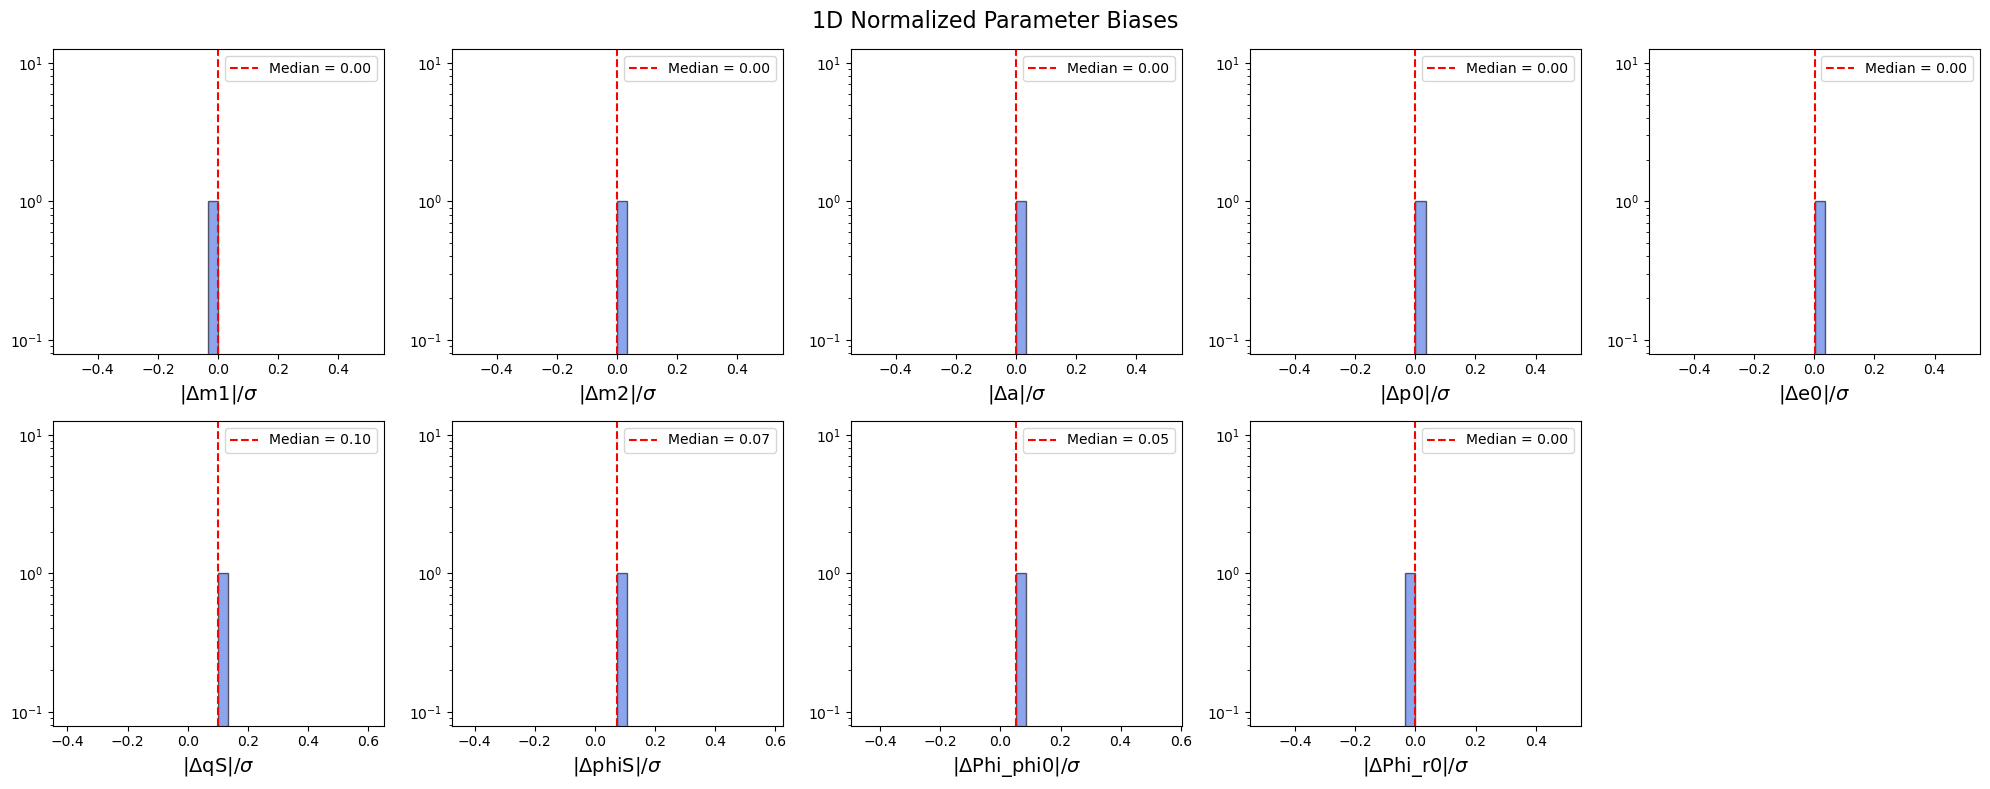

In [39]:
#used gpt (boring part)

# === PARAMETERS ===
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0']


params_truth_in_considered = np.array([
    np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0
])
truevals_i = params_truth_in_considered

Fisher_transformed = Fisher_transform.copy()

# === REMOVE PARAMETERS IF SPECIFIED ===
rows_to_remove = [i for i, name in enumerate(param_names) if name in removed_params]
rows_to_remove = np.array(rows_to_remove)

if len(rows_to_remove) > 0:
    Fisher_transformed = np.delete(Fisher_transformed, rows_to_remove, axis=0)
    Fisher_transformed = np.delete(Fisher_transformed, rows_to_remove, axis=1)
   # param_names_plot = np.delete(param_names_plot, rows_to_remove, axis=0)
    truevals_i = np.delete(truevals_i, rows_to_remove, axis=0)

# === COMPUTE SIGMAS ===
covariance = np.linalg.inv(Fisher_transformed)
sigmas_params = np.sqrt(np.diag(covariance))

# === COMPUTE NORMALIZED BIASES ===
sigmabias_1D = np.abs(biased_params - truevals_i) / sigmas_params

# === PLOT ===
n_params = len(param_names)
ncols = int(np.ceil(n_params / 2))

fig, axs = plt.subplots(2, ncols, figsize=(4 * ncols, 8))
axs = axs.flatten()

for i, name in enumerate(param_names):
    axs[i].hist(sigmabias_1D[i], bins=30, histtype='stepfilled',
                color='royalblue', alpha=0.6, edgecolor='k')
    axs[i].set_xlabel(r"$|\Delta $" + rf"{name}" + r"$|/\sigma$", fontsize=14)
    axs[i].set_yscale('log')
    axs[i].axvline(np.median(sigmabias_1D[i]), color='r', linestyle='--',
                   label=f"Median = {np.median(sigmabias_1D[i]):.2f}")
    axs[i].legend(fontsize=10)

# Hide any unused subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.suptitle("1D Normalized Parameter Biases", fontsize=16)
plt.show()



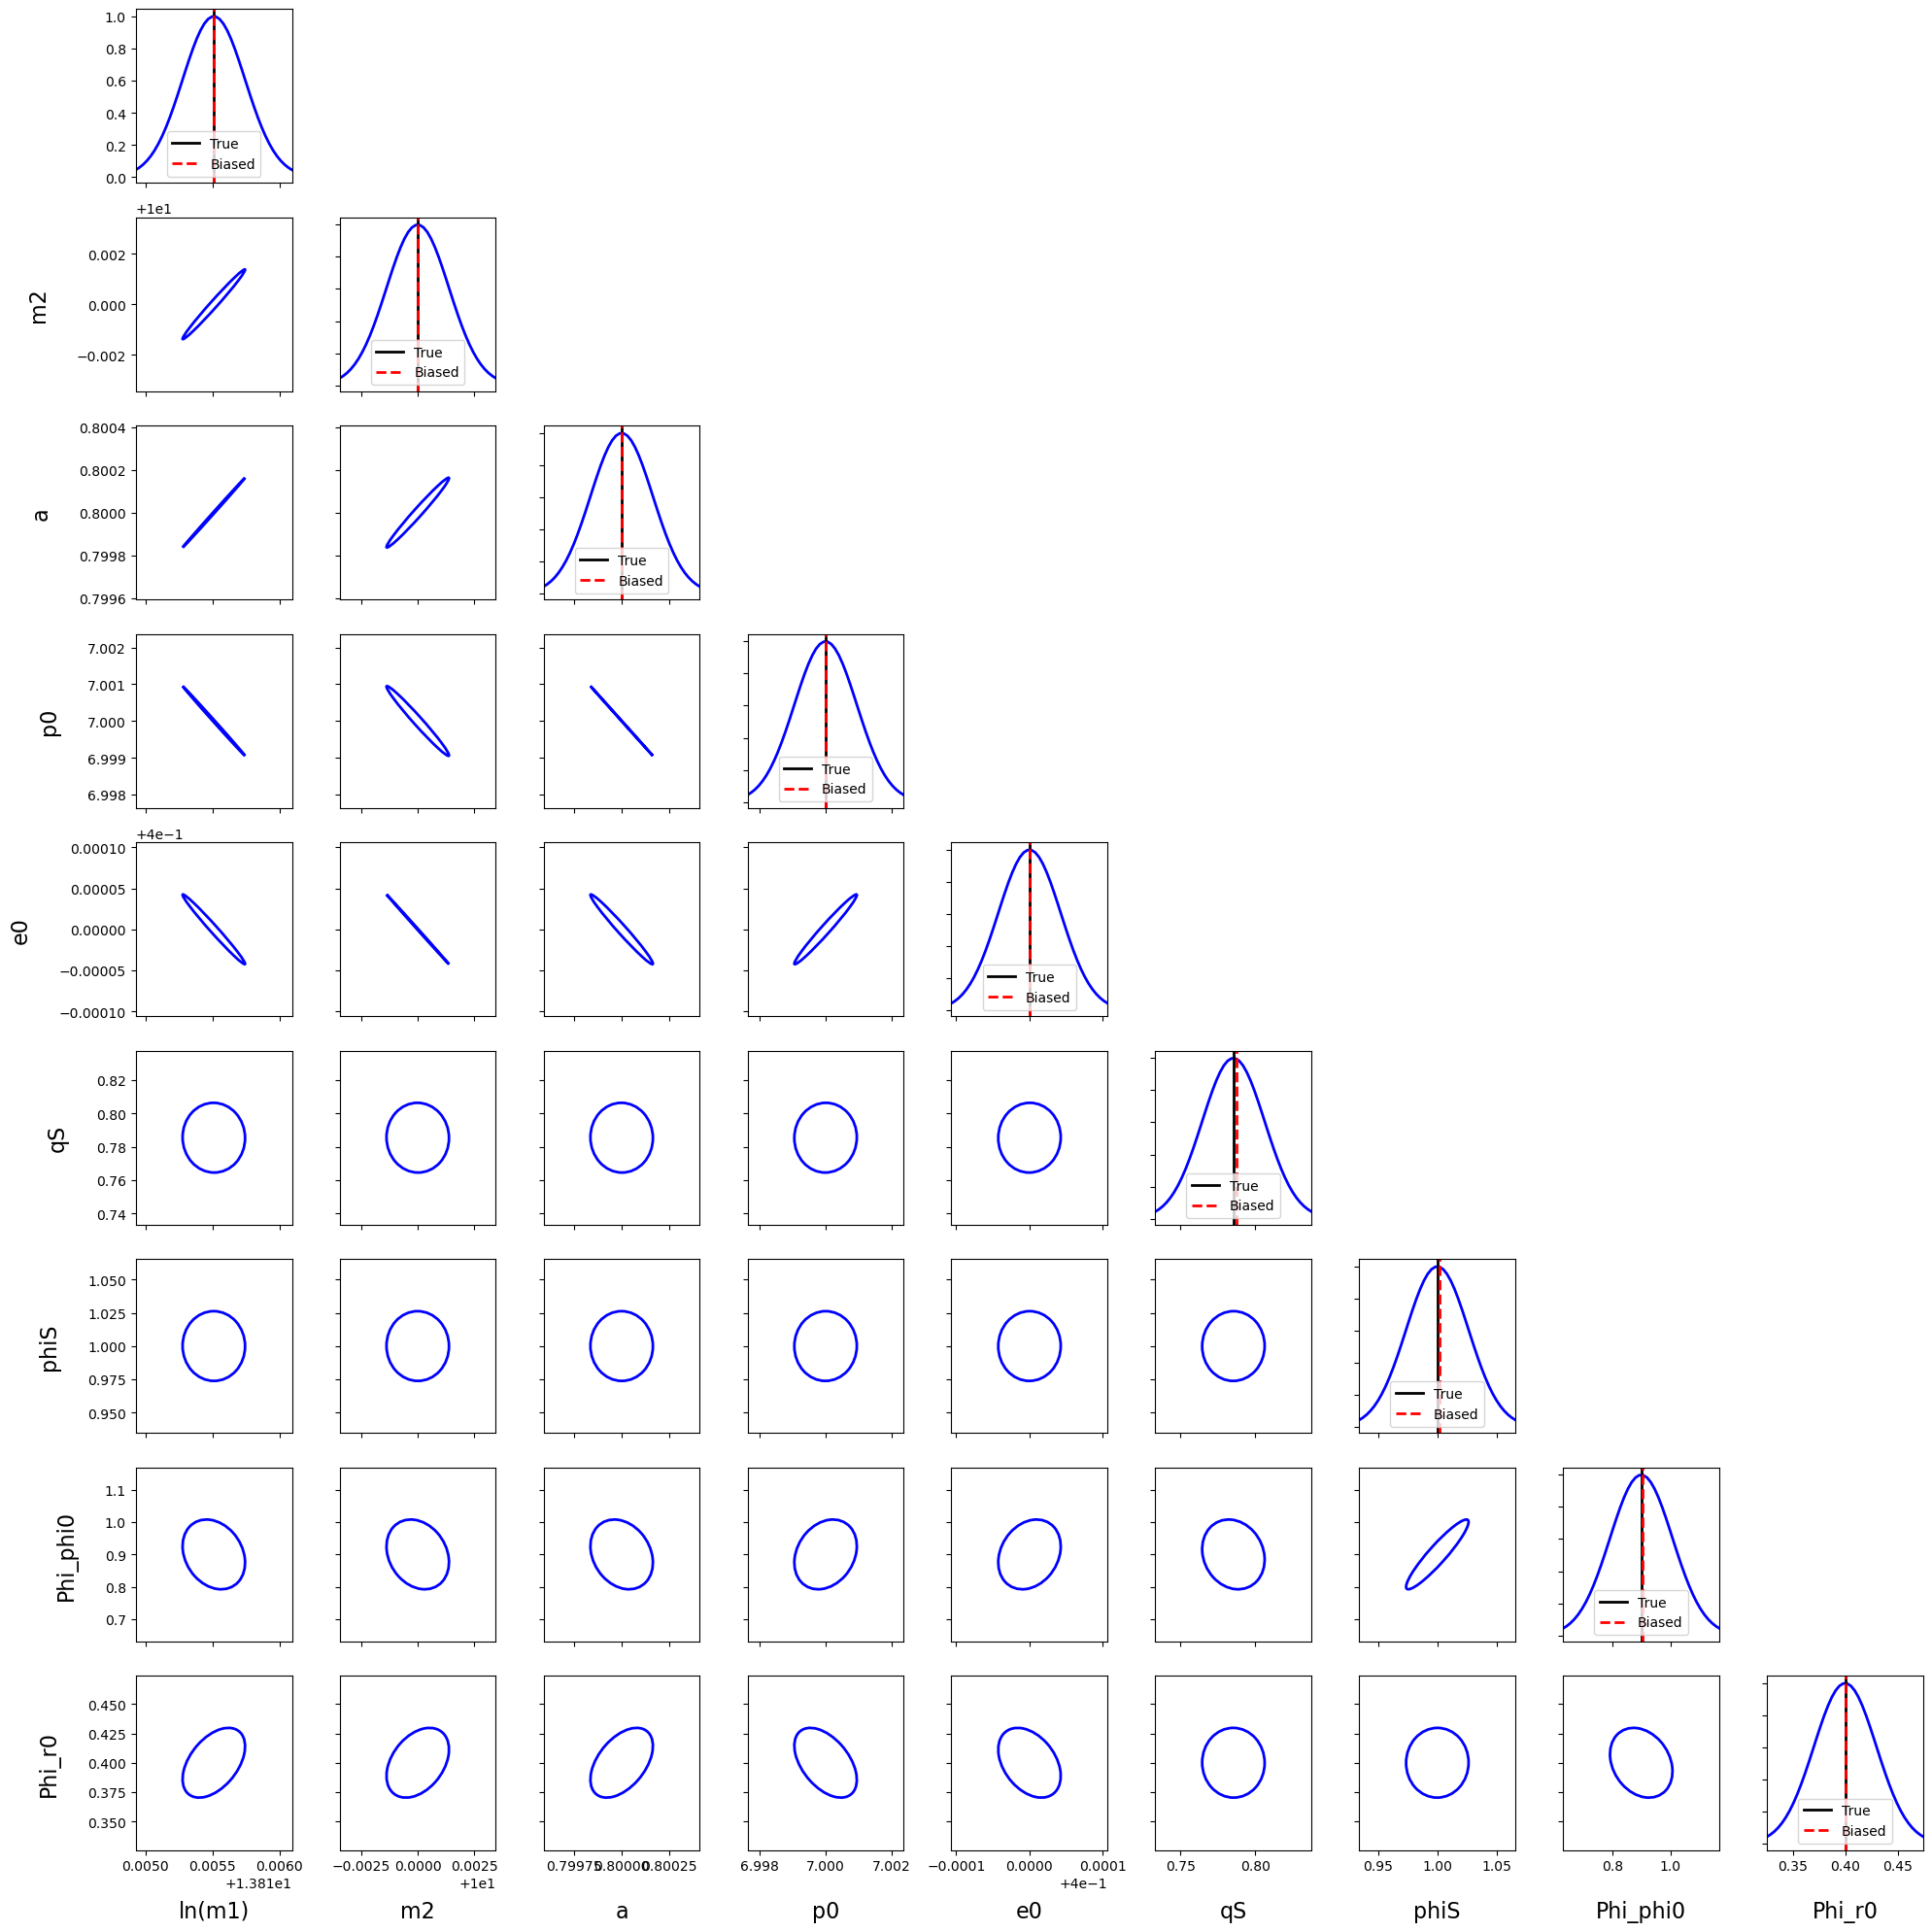

In [40]:
from stableemrifisher.plot import CovEllipsePlot
# pars_list = [m1, m2, p0, e0, dist,qS,phiS,Phi_phi0,Phi_r0,chi2]
# param_names = ['m1','m2','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0','chi2']
pars_list = params_truth_in_considered
# param_names_plot = [
#     r'$\log{m_1}$', r'$m_2$', r'$a$', r'$p_0$', r'$e_0$',
#     r'$\phi_S$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
#     r'dev0_p', r'dev0_e'
# ]
param_names = ['ln(m1)','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0']

wave_params = {}
for i in range(len(pars_list)):
    wave_params[param_names[i]] = params_truth_in_considered[i]

ellipse_kwargs = dict(facecolor='None', edgecolor='b', lw=2)
line_kwargs = dict(lw=2, color='b')

fig, axs = plt.subplots(len(covariance),len(covariance), figsize=(20,20))
fig, axs = CovEllipsePlot(covariance, wave_params=wave_params, param_names=param_names, fig=fig, axs=axs, ellipse_kwargs=ellipse_kwargs, line_kwargs=line_kwargs)
# === ADD TRUE AND BIASED PARAMETER LINES ===
for i in range(len(param_names)):
    # Diagonal subplot (1D)
    ax = axs[i, i]
    ax.axvline(params_truth_in_considered[i], color='k', linestyle='-', lw=2, label='True')
    ax.axvline(biased_params[i], color='r', linestyle='--', lw=2, label='Biased')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


In [41]:
len(pars_list)

9

In [42]:
params_truth_in_considered

array([13.81551056, 10.        ,  0.8       ,  7.        ,  0.4       ,
        0.78539816,  1.        ,  0.9       ,  0.4       ])

In [43]:
biased_params

array([13.81551032,  9.99999862,  0.79999983,  7.000001  ,  0.40000004,
        0.78751418,  1.00196748,  0.905764  ,  0.39999352])

In [52]:
PSD= generate_PSD(waveform_approx-waveform_true,dt)
inner_product(waveform_approx-waveform_true,waveform_approx-waveform_true,PSD,dt)

np.float64(337565.6549537608)

In [53]:
dtv

[array([[ 1.62301658e-26,  1.54310212e-22,  3.93677062e-22, ...,
          4.08395524e-16,  4.14150814e-16,  3.78160517e-16],
        [ 5.06480965e-27, -1.96036328e-22, -2.64687612e-22, ...,
         -2.48058907e-17,  1.03847734e-16,  2.36798884e-16]],
       shape=(2, 1577908)),
 array([[ 1.62301919e-22,  1.37684739e-22,  1.02153878e-22, ...,
         -6.66828405e-18, -6.68293241e-18, -6.03093346e-18],
        [ 5.06479750e-23,  9.50471717e-23,  1.28052522e-22, ...,
          2.84498729e-19, -1.79556471e-18, -3.90860245e-18]],
       shape=(2, 1577908)),
 array([[-4.44429432e-23,  6.33420532e-23,  1.83672986e-22, ...,
          8.01933091e-17,  7.36827797e-17,  6.04167868e-17],
        [-3.29693588e-22, -3.62332441e-22, -3.60828002e-22, ...,
          6.74632717e-18,  3.00260492e-17,  5.05675391e-17]],
       shape=(2, 1577908)),
 array([[-1.11594216e-22, -5.63034348e-23,  2.89195598e-23, ...,
          9.43920121e-17,  9.44615243e-17,  8.51203186e-17],
        [-6.22225454e-23, -1.39